### Step 1: Mount the Google Drive

Remember to use GPU runtime before mounting your Google Drive. (Runtime --> Change runtime type).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

### Step 2: Open the project directory

Replace `Your_Dir` with your own path.

In [ ]:
cd Your_Dir/emg2qwerty

### Step 3: Install required packages

After installing them, Colab will require you to restart the session.

In [ ]:
!pip install -r requirements.txt

Testing GaussianNoiseJitter transform...

Original tensor shape: torch.Size([1000, 2, 16])
Original mean: 0.000331, std: 0.997197

Testing randomness (5 samples):
  Sample 1: noise mean=0.000485, std=0.099983
  Sample 2: noise mean=0.000359, std=0.099335
  Sample 3: noise mean=-0.000066, std=0.100569
  Sample 4: noise mean=-0.000209, std=0.099593
  Sample 5: noise mean=-0.000368, std=0.099161

Noise statistics (10 samples):
  Mean: 0.000386 (expected ~0)
  Std: 0.100026 (expected ~0.01)


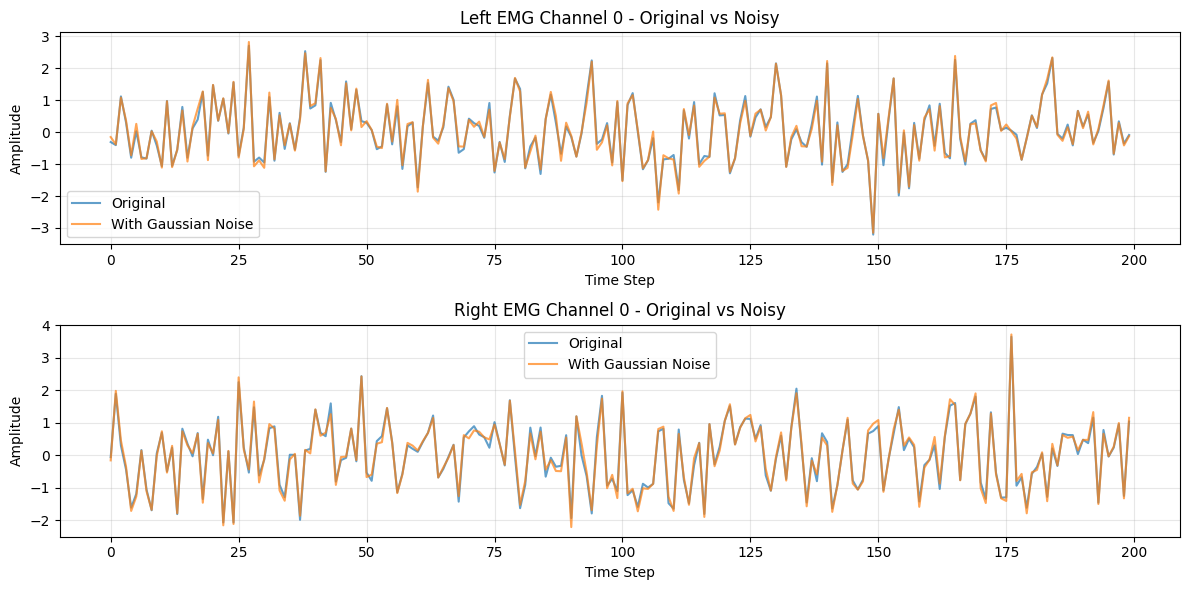


✅ GaussianNoiseJitter transform test completed!

Note: The transform is already added to config/transforms/log_spectrogram.yaml
      It will be automatically applied during training.


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from emg2qwerty.transforms import ToTensor, GaussianNoiseJitter

# Simple direct test - no config needed!
print("Testing GaussianNoiseJitter transform...\n")

# Create synthetic EMG-like data (simulating what comes from HDF5)
time_steps = 1000
channels = 16

emg_left = np.random.randn(time_steps, channels).astype(np.float32)
emg_right = np.random.randn(time_steps, channels).astype(np.float32)
timestamps = np.arange(time_steps, dtype=np.float64)

dtype = np.dtype([
    ('emg_left', np.float32, (channels,)),
    ('emg_right', np.float32, (channels,)),
    ('time', np.float64)
])
structured_data = np.empty(time_steps, dtype=dtype)
structured_data['emg_left'] = emg_left
structured_data['emg_right'] = emg_right
structured_data['time'] = timestamps

# Convert to tensor
to_tensor = ToTensor(fields=('emg_left', 'emg_right'))
tensor_data = to_tensor(structured_data)
print(f"Original tensor shape: {tensor_data.shape}")
print(f"Original mean: {tensor_data.mean().item():.6f}, std: {tensor_data.std().item():.6f}")

# Apply Gaussian noise jitter
noise_transform = GaussianNoiseJitter(std=0.1)
noisy_data = noise_transform(tensor_data.clone())

# Test multiple times to verify randomness
print(f"\nTesting randomness (5 samples):")
for i in range(5):
    noisy = noise_transform(tensor_data.clone())
    noise = noisy - tensor_data
    print(f"  Sample {i+1}: noise mean={noise.mean().item():.6f}, std={noise.std().item():.6f}")

# Verify noise statistics
all_noise = torch.cat([noise_transform(tensor_data.clone()) - tensor_data for _ in range(10)], dim=0)
print(f"\nNoise statistics (10 samples):")
print(f"  Mean: {all_noise.mean().item():.6f} (expected ~0)")
print(f"  Std: {all_noise.std().item():.6f} (expected ~0.01)")

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
time_slice = slice(0, 200)
channel_idx = 0

# Left EMG
axes[0].plot(tensor_data[time_slice, 0, channel_idx].numpy(), 
             label='Original', alpha=0.7, linewidth=1.5)
axes[0].plot(noisy_data[time_slice, 0, channel_idx].numpy(), 
             label='With Gaussian Noise', alpha=0.7, linewidth=1.5)
axes[0].set_title(f'Left EMG Channel {channel_idx} - Original vs Noisy')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Amplitude')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right EMG
axes[1].plot(tensor_data[time_slice, 1, channel_idx].numpy(), 
             label='Original', alpha=0.7, linewidth=1.5)
axes[1].plot(noisy_data[time_slice, 1, channel_idx].numpy(), 
             label='With Gaussian Noise', alpha=0.7, linewidth=1.5)
axes[1].set_title(f'Right EMG Channel {channel_idx} - Original vs Noisy')
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Amplitude')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ GaussianNoiseJitter transform test completed!")
print("\nNote: The transform is already added to config/transforms/log_spectrogram.yaml")
print("      It will be automatically applied during training.")

### Step 4: Start your experiments!

- Remember to download and copy the dataset to this directory: `Your_Dir/emg2qwerty/data`.
- You may now start your experiments with any scripts! Below are examples of single-user training and testing (greedy decoding).
- **There are two ways to track the logs:**
  - 1. Keep `--multirun`, and the logs will not be printed here, but they will be saved in the folder `logs`, e.g., `logs/2025-02-09/18-24-15/submitit_logs/`.
  - 2. Comment out `--multirun` and the logs will be printed in this notebook, but they will not be saved.

#### Training

- The checkpoints are saved in the folder `logs`, e.g., `logs/2025-02-09/18-24-15/checkpoints/`.

In [5]:
# Single-user training
!python -m emg2qwerty.train \
  user="single_user" \
  trainer.accelerator=gpu trainer.devices=1 \
  # --multirun

[2026-02-27 10:55:17,445][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

#### Testing:

- Replace `Your_Path_to_Checkpoint` with your checkpoint path.

In [ ]:
# Single-user testing
!python -m emg2qwerty.train \
  user="single_user" \
  checkpoint="logs/2026-02-26/19-36-25/checkpoints/last.ckpt" \
  train=False trainer.accelerator=gpu \
  decoder=ctc_greedy \
  hydra.launcher.mem_gb=64 \
  # --multirun

[2026-03-01 12:12:26,091][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

In [5]:
!python scripts/run_channel_ablation.py

Channel Ablation Experiments
Running 4 experiments with different channel configurations
Each experiment will train for 15 epochs
CER will be logged to stdout/stderr each epoch

Running experiment: 32 channels
Using all channels
Training for 15 epochs

[2026-03-01 12:25:21,808][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9a

In [1]:
!python scripts/run_downsample_ablation.py

Downsampling Factor Ablation Experiments
Running 4 experiments with different downsampling factors
Each experiment will train for 15 epochs
CER will be logged to stdout/stderr each epoch

Running experiment: downsample_factor=1
No downsampling (baseline)
Training for 15 epochs

[2026-03-05 10:37:52,945][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrok

In [2]:
!python scripts/run_train_fraction_ablation.py

Training Fraction Ablation Experiments
Running 4 experiments with different training fractions
Each experiment will train for 15 epochs
CER will be logged to stdout/stderr each epoch

Running experiment: train_fraction=1.0
Using 100% of training data
Training for 15 epochs

[2026-03-05 10:48:58,086][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-d

In [ ]:
!python -m emg2qwerty.train \
  user="single_user" \
  transforms.train=[${to_tensor},${time_warp},${band_rotation},${temporal_jitter},${logspec},${specaug}] \
  trainer.accelerator=gpu

[2026-03-09 12:32:51,505][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f